In [11]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from gtts import gTTS
from pydub import AudioSegment
from pydub.playback import play
import IPython.display as ipd
import warnings
warnings.filterwarnings('ignore')

In [12]:
# Text-to-Speech for TALK and FOUR
def generate_and_play_audio(word, lang='en'):
   
    print(f"Generating audio for word: {word}")
    
    # Create TTS object
    tts = gTTS(text=word, lang=lang, slow=False)
    
    # Save to file
    filename = f"{word.lower()}.mp3"
    tts.save(filename)
    
    # Convert to wav for analysis
    audio = AudioSegment.from_mp3(filename)
    wav_filename = f"{word.lower()}.wav"
    audio.export(wav_filename, format="wav")
    
    # Play audio
    print(f"Playing audio for '{word}'...")
    display(ipd.Audio(wav_filename))
    
    return wav_filename

# Generate audio for both words
talk_audio = generate_and_play_audio("TALK")
four_audio = generate_and_play_audio("FOUR")

Generating audio for word: TALK
Playing audio for 'TALK'...


Generating audio for word: FOUR
Playing audio for 'FOUR'...



Analysis for: TALK
Total duration: 0.79 seconds
Sample rate: 24000 Hz


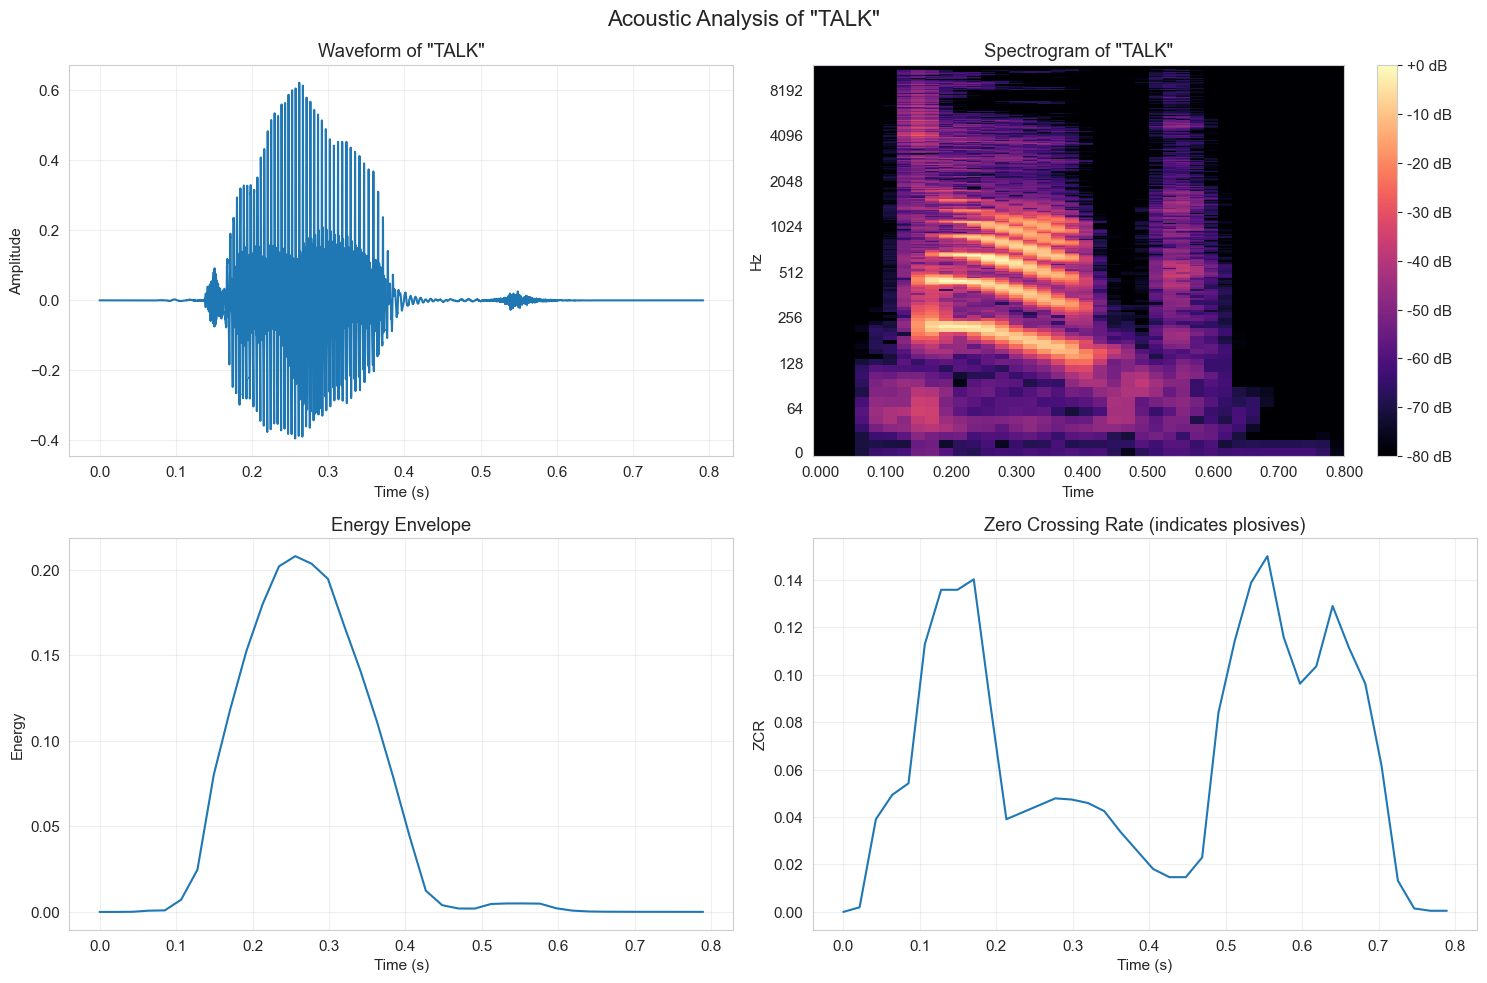


Analysis for: FOUR
Total duration: 0.84 seconds
Sample rate: 24000 Hz


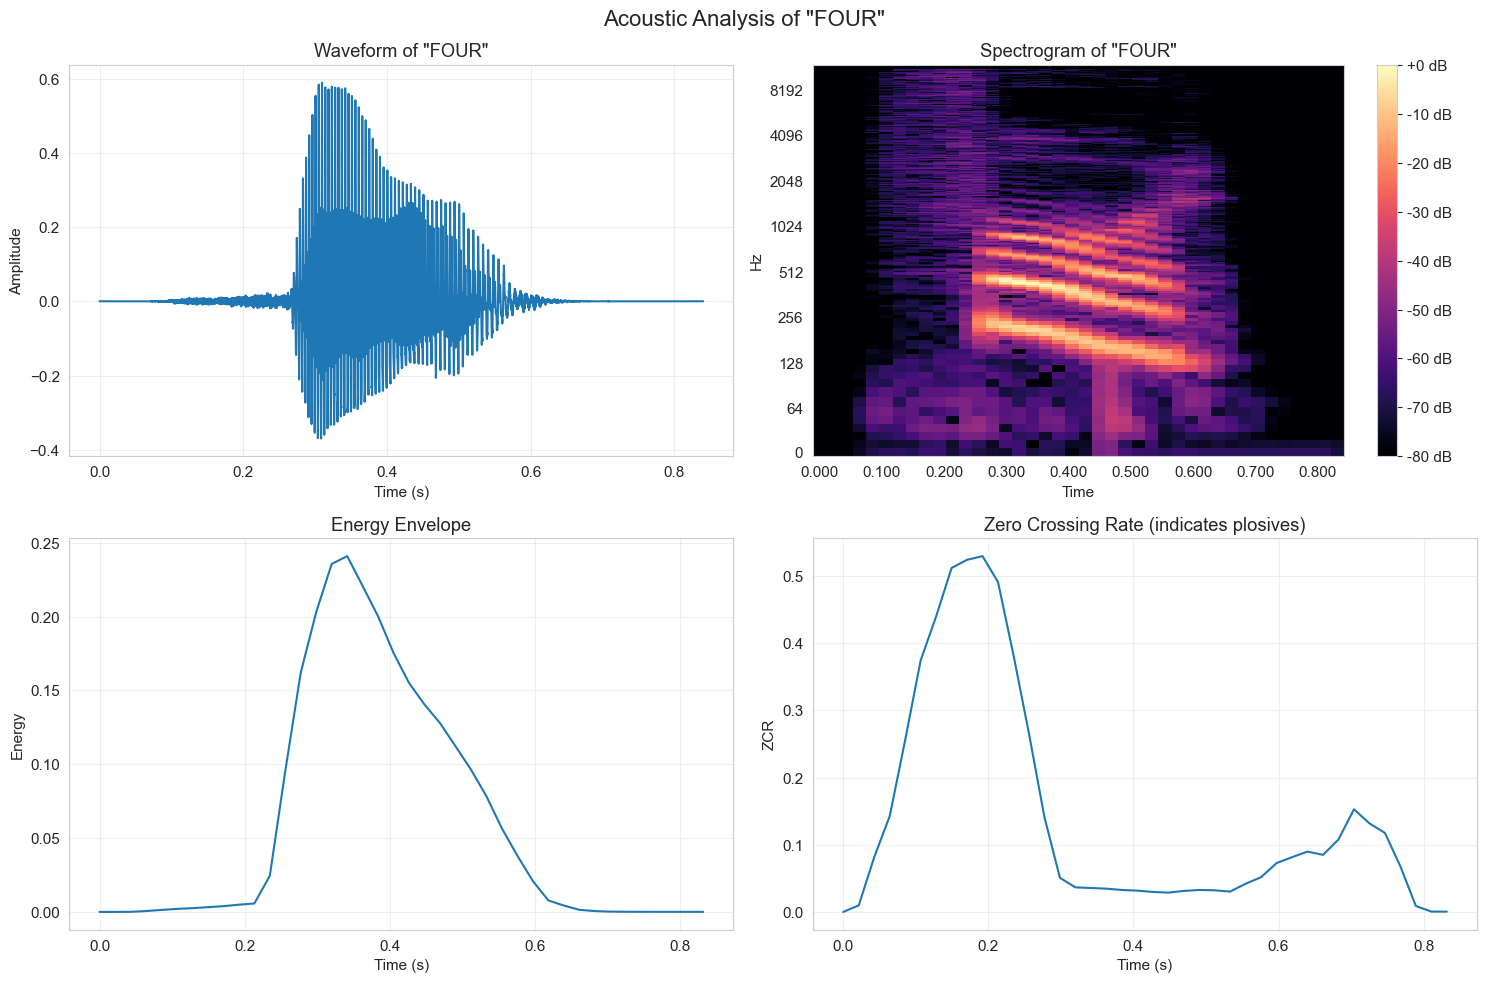

In [13]:
# Visualize and analyze audio waveforms

def analyze_audio(wav_file, word):
    """
    Analyze audio file and visualize waveform + spectrogram
    """
    print(f"\n{'='*50}")
    print(f"Analysis for: {word}")
    print(f"{'='*50}")
    
    # Load audio file
    y, sr = librosa.load(wav_file, sr=None)
    
    # Calculate duration
    duration = len(y) / sr
    print(f"Total duration: {duration:.2f} seconds")
    print(f"Sample rate: {sr} Hz")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Acoustic Analysis of "{word}"', fontsize=16)
    
    # 1. Waveform
    axes[0, 0].plot(np.arange(len(y)) / sr, y)
    axes[0, 0].set_title(f'Waveform of "{word}"')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=axes[0, 1])
    axes[0, 1].set_title(f'Spectrogram of "{word}"')
    fig.colorbar(img, ax=axes[0, 1], format="%+2.0f dB")
    
    # 3. Energy envelope
    energy = librosa.feature.rms(y=y)[0]
    times = librosa.times_like(energy, sr=sr)
    axes[1, 0].plot(times, energy)
    axes[1, 0].set_title('Energy Envelope')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Energy')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Zero-crossing rate (for plosive detection)
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    times_zcr = librosa.times_like(zcr, sr=sr)
    axes[1, 1].plot(times_zcr, zcr)
    axes[1, 1].set_title('Zero Crossing Rate (indicates plosives)')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('ZCR')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return y, sr, duration

# Analyze both words
y_talk, sr_talk, dur_talk = analyze_audio(talk_audio, "TALK")
y_four, sr_four, dur_four = analyze_audio(four_audio, "FOUR")

In [14]:
# HMM Analysis for TALK - Task 1a

print("=" * 70)
print("TASK 1a: HMM Structural Analysis for TALK")
print("=" * 70)

# Define HMM states for TALK
states = ['S1=/t/', 'S2=/ɔː/', 'S3=/k/']
print(f"\nPhoneme states for 'TALK': {states}")

# Transition matrix (simplified)
print("\n" + "=" * 50)
print("Transition Probability Matrix for TALK (Left-to-Right HMM)")
print("=" * 50)

# Create transition matrix
transition_matrix = np.array([
    # From \ To:  S1=/t/  S2=/ɔː/  S3=/k/
    [0.1,        0.9,     0.0],    # From S1
    [0.0,        0.7,     0.3],    # From S2 (NO backward transition to S1)
    [0.0,        0.0,     0.4]     # From S3 (NO backward transitions at all)
])

# Display the matrix
print("\nTransition Matrix:")
print("     S1=/t/   S2=/ɔː/   S3=/k/")
print("     " + "-"*35)
for i, row in enumerate(transition_matrix):
    print(f"S{i+1}  ", end="")
    for j, val in enumerate(row):
        print(f"  {val:.2f}    ", end="")
    print()

# Highlight zero backward transitions
print("\n" + "="*50)
print("KEY OBSERVATIONS for Part 1a:")
print("="*50)
print("1. P(/k/ → /t/) = 0.00: Cannot transition from final /k/ back to initial /t/")
print("2. P(/ɔː/ → /t/) = 0.00: Cannot transition from vowel back to initial consonant")
print("3. P(/t/ → /k/) = 0.00: Cannot skip the vowel /ɔː/")
print("\nLinguistic Property: FIXED PHONEME ORDERING")
print("- The word must be pronounced as /t/ → /ɔː/ → /k/")
print("- This ensures temporal sequence: t → ɔː → k")
print("- Enforces correct pronunciation: 't-aw-k' not 'k-aw-t' or 'aw-t-k'")

TASK 1a: HMM Structural Analysis for TALK

Phoneme states for 'TALK': ['S1=/t/', 'S2=/ɔː/', 'S3=/k/']

Transition Probability Matrix for TALK (Left-to-Right HMM)

Transition Matrix:
     S1=/t/   S2=/ɔː/   S3=/k/
     -----------------------------------
S1    0.10      0.90      0.00    
S2    0.00      0.70      0.30    
S3    0.00      0.00      0.40    

KEY OBSERVATIONS for Part 1a:
1. P(/k/ → /t/) = 0.00: Cannot transition from final /k/ back to initial /t/
2. P(/ɔː/ → /t/) = 0.00: Cannot transition from vowel back to initial consonant
3. P(/t/ → /k/) = 0.00: Cannot skip the vowel /ɔː/

Linguistic Property: FIXED PHONEME ORDERING
- The word must be pronounced as /t/ → /ɔː/ → /k/
- This ensures temporal sequence: t → ɔː → k
- Enforces correct pronunciation: 't-aw-k' not 'k-aw-t' or 'aw-t-k'



TASK 1b: Phoneme Duration Analysis

Given transition probabilities:
  P(/t/ → /t/) = 0.1
  P(/ɔː/ → /ɔː/) = 0.7

Expected duration in each state (in frames/time units):
  Expected frames in /t/ state = 1/(1-0.1) = 1.11
  Expected frames in /ɔː/ state = 1/(1-0.7) = 3.33

Duration Ratio (/ɔː/ : /t/) = 3.00:1
  → Vowel /ɔː/ is expected to last 3.0 times longer than /t/

VISUAL EXPLANATION:


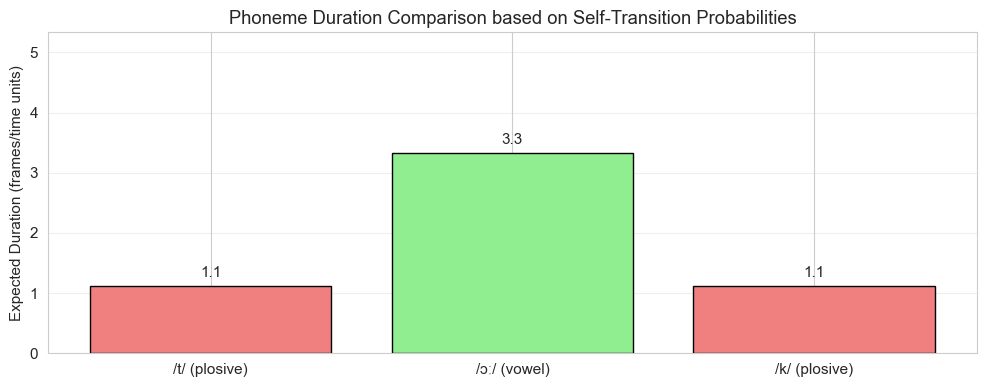


ACOUSTIC REASONING from TTS Output:
1. /t/ is a PLOSIVE: Short, burst-like sound (~50-100ms)
   - Quick release of air
   - Low self-transition (0.1) = short duration

2. /ɔː/ is a VOWEL: Sustained, steady-state sound
   - Can be prolonged naturally
   - High self-transition (0.7) = longer duration
   - Audible as the 'AW' sound in 'TALK'

3. /k/ is another PLOSIVE: Similar to /t/ but velar
   - Also short and burst-like


In [15]:
# Duration Analysis for TALK - Task 1b

print("\n" + "=" * 70)
print("TASK 1b: Phoneme Duration Analysis")
print("=" * 70)

# Given transition probabilities
p_t_self = 0.1  # P(S1 to S1)
p_vowel_self = 0.7  # P(S2 to S2)

# Calculate expected duration using geometric distribution
# Expected duration in states = 1 / (1 - self_transition_probability)
expected_duration_t = 1 / (1 - p_t_self)
expected_duration_vowel = 1 / (1 - p_vowel_self)

print(f"\nGiven transition probabilities:")
print(f"  P(/t/ → /t/) = {p_t_self}")
print(f"  P(/ɔː/ → /ɔː/) = {p_vowel_self}")

print(f"\nExpected duration in each state (in frames/time units):")
print(f"  Expected frames in /t/ state = 1/(1-{p_t_self}) = {expected_duration_t:.2f}")
print(f"  Expected frames in /ɔː/ state = 1/(1-{p_vowel_self}) = {expected_duration_vowel:.2f}")

duration_ratio = expected_duration_vowel / expected_duration_t
print(f"\nDuration Ratio (/ɔː/ : /t/) = {duration_ratio:.2f}:1")
print(f"  → Vowel /ɔː/ is expected to last {duration_ratio:.1f} times longer than /t/")

# Visualization of phoneme durations
print("\n" + "="*50)
print("VISUAL EXPLANATION:")
print("="*50)

# Create visualization
fig, ax = plt.subplots(figsize=(10, 4))

# Phoneme durations based on transition probabilities
phonemes = ['/t/ (plosive)', '/ɔː/ (vowel)', '/k/ (plosive)']
durations = [expected_duration_t, expected_duration_vowel, expected_duration_t]

colors = ['lightcoral', 'lightgreen', 'lightcoral']
bars = ax.bar(phonemes, durations, color=colors, edgecolor='black')

# Add value labels
for bar, duration in zip(bars, durations):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{duration:.1f}', ha='center', va='bottom')

ax.set_ylabel('Expected Duration (frames/time units)')
ax.set_title('Phoneme Duration Comparison based on Self-Transition Probabilities')
ax.set_ylim(0, max(durations) + 2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("ACOUSTIC REASONING from TTS Output:")
print("="*50)
print("1. /t/ is a PLOSIVE: Short, burst-like sound (~50-100ms)")
print("   - Quick release of air")
print("   - Low self-transition (0.1) = short duration")
print("\n2. /ɔː/ is a VOWEL: Sustained, steady-state sound")
print("   - Can be prolonged naturally")
print("   - High self-transition (0.7) = longer duration")
print("   - Audible as the 'AW' sound in 'TALK'")
print("\n3. /k/ is another PLOSIVE: Similar to /t/ but velar")
print("   - Also short and burst-like")

In [16]:
# Viterbi Algorithm Implementation

print("=" * 70)
print("VITERBI DECODING DEMONSTRATION")
print("=" * 70)

def viterbi_algorithm(observations, states, start_p, trans_p, emit_p):
    """
    Simplified Viterbi algorithm for HMM decoding
    """
    V = [{}]
    path = {}
    
    # Initialize base cases (t == 0)
    for state in states:
        V[0][state] = start_p[state] * emit_p[state][observations[0]]
        path[state] = [state]
    
    # Run Viterbi for t > 0
    for t in range(1, len(observations)):
        V.append({})
        newpath = {}
        
        for curr_state in states:
            # Find maximum probability
            (prob, state) = max(
                (V[t-1][prev_state] * trans_p[prev_state][curr_state] * emit_p[curr_state][observations[t]], prev_state)
                for prev_state in states
            )
            V[t][curr_state] = prob
            newpath[curr_state] = path[state] + [curr_state]
        
        # Don't need to remember the old paths
        path = newpath
    
    # Find the final state with maximum probability
    n = len(observations) - 1
    (prob, state) = max((V[n][state], state) for state in states)
    
    return prob, path[state]

# Example for the word TALK
print("\nExample: Decoding observations for 'TALK'")

# Define states
states_talk = ['S1=/t/', 'S2=/ɔː/', 'S3=/k/']

# Start probabilities (must start with S1)
start_probability = {'S1=/t/': 1.0, 'S2=/ɔː/': 0.0, 'S3=/k/': 0.0}

# Transition probabilities (from the given matrix)
transition_probability = {
    'S1=/t/': {'S1=/t/': 0.1, 'S2=/ɔː/': 0.9, 'S3=/k/': 0.0},
    'S2=/ɔː/': {'S1=/t/': 0.0, 'S2=/ɔː/': 0.7, 'S3=/k/': 0.3},
    'S3=/k/': {'S1=/t/': 0.0, 'S2=/ɔː/': 0.0, 'S3=/k/': 0.4}
}

# Simplified emission probabilities (observations: acoustic features)
# Let's say we have 3 possible observations: O1, O2, O3
observations_talk = ['O1', 'O2', 'O2', 'O2', 'O3']  # O2 repeated for vowel duration

# Emission probabilities
emission_probability = {
    'S1=/t/': {'O1': 0.8, 'O2': 0.1, 'O3': 0.1},
    'S2=/ɔː/': {'O1': 0.1, 'O2': 0.8, 'O3': 0.1},
    'S3=/k/': {'O1': 0.1, 'O2': 0.1, 'O3': 0.8}
}

# Run Viterbi
prob, path = viterbi_algorithm(observations_talk, states_talk, 
                               start_probability, 
                               transition_probability, 
                               emission_probability)

print(f"\nObservations: {observations_talk}")
print(f"Most likely state sequence: {path}")
print(f"Probability: {prob:.6f}")

print("\n" + "="*50)
print("INTERPRETATION:")
print("="*50)
print("1. The algorithm finds the most likely phoneme sequence")
print("2. Multiple O2 observations → S2 stays in vowel state (self-transition)")
print("3. This models the longer duration of the vowel /ɔː/")
print("4. The left-to-right structure ensures correct order: /t/ → /ɔː/ → /k/")

VITERBI DECODING DEMONSTRATION

Example: Decoding observations for 'TALK'

Observations: ['O1', 'O2', 'O2', 'O2', 'O3']
Most likely state sequence: ['S1=/t/', 'S2=/ɔː/', 'S2=/ɔː/', 'S2=/ɔː/', 'S3=/k/']
Probability: 0.043352

INTERPRETATION:
1. The algorithm finds the most likely phoneme sequence
2. Multiple O2 observations → S2 stays in vowel state (self-transition)
3. This models the longer duration of the vowel /ɔː/
4. The left-to-right structure ensures correct order: /t/ → /ɔː/ → /k/
